# $\mathbb{Z}_2^F \times \mathbb{Z}_2^T$ - Majorana Hamiltonians - open boundary conditions

Created: 04-08-2026

Iterate on [previous notebook](z2_f_x_z2_t_majorana_hamiltonians.ipynb), now just doing open boundary conditions.

# Imports

In [1]:
from time import time

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from tqdm import tqdm

In [5]:
from functools import reduce
from itertools import product

In [6]:
import quimb.tensor as qtn
import quimb as qu

In [7]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d, tensor_basis

In [8]:
from humanize import naturalsize

# Definitions

In [9]:
group_quads = list(product([0,1], repeat=4))

In [10]:
spin_ops_dict = {
    (0,0): [("I", 1), ("y", 1)],
    (1,1): [("I", 1), ("y", -1)],
    (0,1): [("z", 1), ("x", 1j)],
    (1,0): [("z", 1), ("x", -1j)]
}

In [11]:
majorana_1 = [('+', 1) ,('-', 1)]
majorana_2 = [('+', 1j),  ('-', -1j)]

In [12]:
def get_triv_terms(L, strength_scaling=1):
    terms = [
        ['z|', [[-1*strength_scaling, i] for i in range(L)]],
        ['|n', [[strength_scaling, i] for i in range(L)]],
        ['|I', [[-1*strength_scaling, i] for i in range(L)]],
    ]

    return terms

In [13]:
def get_triv_cocycle_nontriv_fermion_decoration_terms(L, strength_scaling=1):
    ss = strength_scaling

    spin_terms=[
        [f'z|{op_l}{op_r}', [[-1j*s_l*s_r*ss, i+1, i, i+1] for i in range(L-1)]]
        for op_l, s_l in majorana_2
        for op_r, s_r in majorana_1
    ]

    fermion_terms = [
        [f'yy|I', [[-1*ss, i, i+1, i] for i in range(L-1)]],
        [f'yy|n', [[2*ss, i, i+1, i] for i in range(L-1)]]
    ]

    terms = spin_terms + fermion_terms

    return terms

In [14]:
def cocycle_phase(group_quad):
    g_left, g_in, g_out, g_right = group_quad

    exponent = (
        (g_in - g_left)*(g_right - g_in)
        - (g_out - g_left)*(g_right - g_out)
    )
    exponent = exponent % 2

    # i.e. (-1)**exponent
    out = -1 if exponent else 1

    return out

In [15]:
majorana_hopping_terms = [
    (f'{op_l}{op_r}', -1j*s_l*s_r, (0, 1))
    for op_l, s_l in majorana_2
    for op_r, s_r in majorana_1
]

In [16]:
majorana_hopping_terms

[('++', (1-0j), (0, 1)),
 ('+-', (1-0j), (0, 1)),
 ('-+', (-1+0j), (0, 1)),
 ('--', (-1+0j), (0, 1))]

In [17]:
def get_nontriv_group_quad_terms(group_quad, L, strength_scaling=1):
    g_left, g_in, g_out, g_right = group_quad

    left_op = spin_ops_dict[(g_left, g_left)]
    mid_op = spin_ops_dict[(g_out, g_in)]
    right_op = spin_ops_dict[(g_right, g_right)]

    op_triples = product(left_op, mid_op, right_op)

    terms = list()

    for left_pair, mid_pair, right_pair in op_triples:
        left_string, left_strength = left_pair
        mid_string, mid_strength = mid_pair
        right_string, right_strength = right_pair

        spin_string = f"{left_string}{mid_string}{right_string}"
        strength = -(1/16)*left_strength*mid_strength*right_strength

        # Cases where we have majorana hopping or not
        if (g_in + g_out)%2:
            for ferm_op_string, ferm_strength, ferm_indices in majorana_hopping_terms:
                op_string = f"{spin_string}|{ferm_op_string}"
    
                base_index = [0, 1, 2, *ferm_indices]
                all_indices = [
                    [x+i for x in base_index]
                    for i in range(L-2)
                ]
        
                phase = cocycle_phase(group_quad)
                scaling_constant = (
                    strength
                    *strength_scaling
                    *cocycle_phase(group_quad)
                    *ferm_strength
                )
                current_term = [
                    op_string, [[scaling_constant, *indices] for indices in all_indices]
                ]
        
                terms.append(current_term)
        else:
            op_string = f"{spin_string}|"

            base_index = [0, 1, 2]
            all_indices = [
                [x+i for x in base_index]
                for i in range(L-2)
            ]
    
            phase = cocycle_phase(group_quad)
            scaling_constant = (
                strength
                *strength_scaling
                *cocycle_phase(group_quad)
            )
            current_term = [
                op_string, [[scaling_constant, *indices] for indices in all_indices]
            ]
    
            terms.append(current_term)

    return terms

In [18]:
def get_nontriv_cocycle_nontriv_fermion_decoration_terms(L, strength_scaling=1):
    spin_terms = [
        l for group_quad in group_quads
        for l in get_nontriv_group_quad_terms(group_quad, L, strength_scaling)
    ]

    fermion_terms = [
        [f'yy|I', [[-1, i, i+1, i] for i in range(L-1)]],
        [f'yy|n', [[2, i, i+1, i] for i in range(L-1)]]
    ]

    terms = spin_terms + fermion_terms

    return terms

In [19]:
def get_triv_to_n1_non_triv_hamiltonian(t, L):
    spin_basis = spin_basis_1d(L)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    triv_terms = get_triv_terms(L, 1-t)

    non_triv_terms = get_triv_cocycle_nontriv_fermion_decoration_terms(
        L,
        t
    )

    all_terms = triv_terms + non_triv_terms

    h = hamiltonian(
        all_terms,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return h

In [20]:
def get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L):
    spin_basis = spin_basis_1d(L)
    fermion_basis = spinless_fermion_basis_1d(L)
    basis = tensor_basis(spin_basis, fermion_basis)

    triv_terms = get_triv_cocycle_nontriv_fermion_decoration_terms(
        L,
        1-t
    )

    non_triv_spin_terms = [
        l for group_quad in group_quads
        for l in get_nontriv_group_quad_terms(group_quad, L, t)
    ]

    non_triv_fermion_terms = [
        [f'yy|I', [[-1*t, i, (i+1)%L, i] for i in range(L)]],
        [f'yy|n', [[2*t, i, (i+1)%L, i] for i in range(L)]]
    ]

    all_terms = (
        triv_terms
        + non_triv_spin_terms
        + non_triv_fermion_terms
    )

    h = hamiltonian(
        all_terms,
        [],
        basis=basis,
        dtype=np.complex128,
        check_symm=False,
        check_herm=False
    )

    return h

Test energies:

In [21]:
L=4

In [22]:
parameters = np.linspace(0, 1, 21)

In [23]:
triv_energies = list()

L=4
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

for t in parameters:
    h = get_triv_to_n1_non_triv_hamiltonian(t, L)
    e, psi = h.eigsh(k=12, which='SA')

    idx = np.argsort(e)
    e = e[idx]
    psi = psi[:, idx]

    triv_energies.append(e)

/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_47083/2905373412.py:15: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_47083/2905373412.py:15: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(


In [24]:
triv_energies = np.array(triv_energies)

In [25]:
np.round(triv_energies, 3)

array([[-8.   , -7.   , -7.   , -7.   , -7.   , -6.   , -6.   , -6.   ,
        -6.   , -6.   , -6.   , -6.   ],
       [-7.606, -6.736, -6.684, -6.622, -6.574, -5.814, -5.786, -5.752,
        -5.735, -5.704, -5.7  , -5.674],
       [-7.225, -6.482, -6.374, -6.252, -6.159, -5.631, -5.584, -5.508,
        -5.481, -5.416, -5.401, -5.357],
       [-6.86 , -6.24 , -6.072, -5.89 , -5.757, -5.452, -5.396, -5.27 ,
        -5.238, -5.137, -5.102, -5.053],
       [-6.513, -6.011, -5.778, -5.54 , -5.372, -5.276, -5.225, -5.038,
        -5.008, -4.87 , -4.805, -4.763],
       [-6.189, -5.797, -5.494, -5.204, -5.102, -5.073, -5.008, -4.813,
        -4.796, -4.682, -4.616, -4.509],
       [-5.892, -5.601, -5.22 , -4.945, -4.929, -4.888, -4.668, -4.654,
        -4.603, -4.597, -4.377, -4.311],
       [-5.628, -5.424, -4.96 , -4.845, -4.756, -4.641, -4.596, -4.434,
        -4.392, -4.36 , -4.229, -4.177],
       [-5.404, -5.27 , -4.777, -4.716, -4.643, -4.582, -4.336, -4.292,
        -4.202, -4.158, 

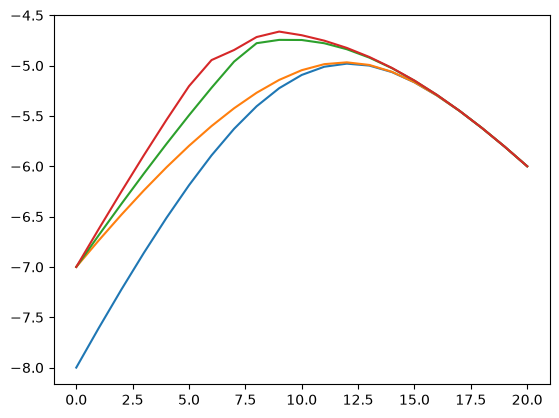

In [26]:
plt.plot(triv_energies[:, :4])

Nice plot.

In [27]:
non_triv_energies = list()

L=4
spin_basis = spin_basis_1d(L)
fermion_basis = spinless_fermion_basis_1d(L)
basis = tensor_basis(spin_basis, fermion_basis)

for t in parameters:
    h = get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L)
    e, psi = h.eigsh(k=12, which='SA')

    idx = np.argsort(e)
    e = e[idx]
    psi = psi[:, idx]

    non_triv_energies.append(e)

/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_47083/662957289.py:27: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(


In [28]:
non_triv_energies = np.array(non_triv_energies)

In [29]:
non_triv_energies

array([[-6.        , -6.        , -6.        , -6.        , -4.        ,
        -4.        , -4.        , -4.        , -4.        , -4.        ,
        -2.        , -2.        ],
       [-5.95049336, -5.95049336, -5.85049336, -5.85049336, -4.07532889,
        -4.07532889, -4.04983558, -4.04983558, -4.02532889, -4.02532889,
        -3.97532889, -3.97532889],
       [-5.90208213, -5.90208213, -5.70208213, -5.70208213, -4.15138782,
        -4.15138782, -4.09930649, -4.09930649, -4.05138782, -4.05138782,
        -3.95138782, -3.95138782],
       [-5.85495602, -5.85495602, -5.55495602, -5.55495602, -4.22830241,
        -4.22830241, -4.1483512 , -4.1483512 , -4.07830241, -4.07830241,
        -3.92830241, -3.92830241],
       [-5.80934773, -5.80934773, -5.40934773, -5.40934773, -4.30622577,
        -4.30622577, -4.19689618, -4.19689618, -4.10622577, -4.10622577,
        -3.90622577, -3.90622577],
       [-5.76554464, -5.76554464, -5.26554464, -5.26554464, -4.38534532,
        -4.38534532, -

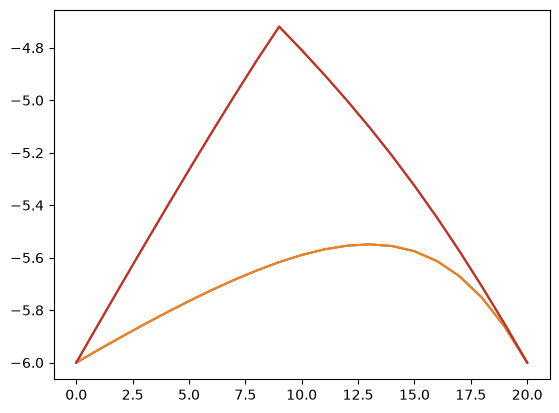

In [30]:
plt.plot(non_triv_energies[:, :4])

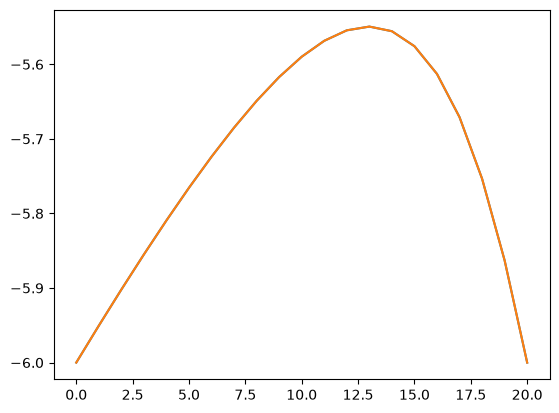

In [31]:
plt.plot(non_triv_energies[:, :2])

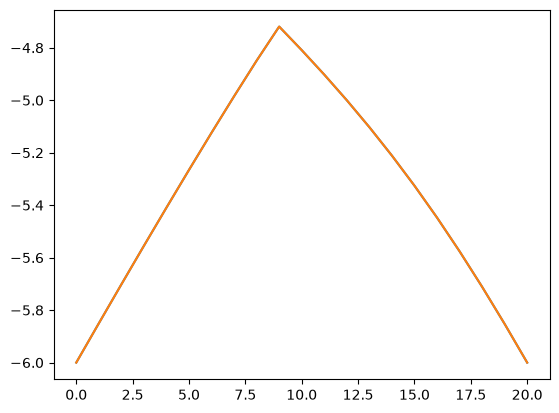

In [32]:
plt.plot(non_triv_energies[:, 2:4])

Different kinds of phase transitions happening for different groundstates? Interesting...

# Sweep

In [29]:
parameters = np.linspace(0, 1, 21)

## 4 site

In [30]:
L = 4

## Trivial cocycle

In [31]:
for t in tqdm(parameters):
    h = get_triv_to_n1_non_triv_hamiltonian(t, L)
    e, psi = h.eigsh(k=12, which='SA')

    idx = np.argsort(e)
    e = e[idx]
    psi = psi[:, idx]

    t_string = str(int(100*t))
    np.savez(rf'../data/z2_f_x_z2_t_majorana_triv_to_nontriv_n1_4_site_ed_obc/{t_string}.npz', energy=e, psi=psi)

  0%|                                                                                         | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_46017/2905373412.py:15: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 63.27it/s]


## Nontrivial cocycle

In [32]:
for t in tqdm(parameters):
    h = get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L)
    e, psi = h.eigsh(k=12, which='SA')

    idx = np.argsort(e)
    e = e[idx]
    psi = psi[:, idx]

    t_string = str(int(100*t))
    np.savez(rf'../data/z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_4_site_ed_obc/{t_string}.npz', energy=e, psi=psi)

  0%|                                                                                         | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_46017/662957289.py:27: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [00:00<00:00, 57.39it/s]


## 8 site

In [33]:
L = 8

## Trivial cocycle

In [34]:
for t in tqdm(parameters):
    h = get_triv_to_n1_non_triv_hamiltonian(t, L)
    e, psi = h.eigsh(k=12, which='SA')

    idx = np.argsort(e)
    e = e[idx]
    psi = psi[:, idx]

    t_string = str(int(100*t))
    np.savez(rf'../data/z2_f_x_z2_t_majorana_triv_to_nontriv_n1_8_site_ed_obc/{t_string}.npz', energy=e, psi=psi)

  0%|                                                                                         | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_46017/2905373412.py:15: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [01:46<00:00,  5.09s/it]


## Nontrivial cocycle

In [35]:
for t in tqdm(parameters):
    h = get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L)
    e, psi = h.eigsh(k=12, which='SA')

    idx = np.argsort(e)
    e = e[idx]
    psi = psi[:, idx]

    t_string = str(int(100*t))
    np.savez(rf'../data/z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_8_site_ed_obc/{t_string}.npz', energy=e, psi=psi)

  0%|                                                                                         | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_46017/662957289.py:27: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [01:40<00:00,  4.79s/it]


## 10 site

In [33]:
L = 10

## Trivial cocycle

In [34]:
for t in tqdm(parameters):
    h = get_triv_to_n1_non_triv_hamiltonian(t, L)
    e, psi = h.eigsh(k=1, which='SA')

    t_string = str(int(100*t))
    np.savez(rf'../data/z2_f_x_z2_t_majorana_triv_to_nontriv_n1_10_site_ed_obc/{t_string}.npz', energy=e, psi=psi)

  0%|                                                                                         | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_47083/2905373412.py:15: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [08:06<00:00, 23.19s/it]


## Nontrivial cocycle

In [35]:
for t in tqdm(parameters):
    h = get_nontriv_n1_to_nontriv_cocycle_hamiltonian(t, L)
    e, psi = h.eigsh(k=1, which='SA')

    t_string = str(int(100*t))
    np.savez(rf'../data/z2_f_x_z2_t_majorana_nontriv_n1_to_nontriv_cocyle_10_site_ed_obc/{t_string}.npz', energy=e, psi=psi)

  0%|                                                                                         | 0/21 [00:00<?, ?it/s]/var/folders/r3/xn8xq5c17932m2g1b4r3dss80000gn/T/ipykernel_47083/662957289.py:27: UserWarning: Test for particle conservation not implemented for <class 'quspin.basis.tensor.tensor_basis'>, to turn off this warning set check_pcon=False in hamiltonian
  h = hamiltonian(
100%|████████████████████████████████████████████████████████████████████████████████| 21/21 [08:14<00:00, 23.57s/it]
